## 1.2 Classification.     
Classification is a type of supervised machine learning where the goal is to predict a categorical label(class) for a given input based on previously labelled training data.     

__Types of classification__.   
1. Binary Classification: Predicts one of two possible classes e.g email filtering i.e in an email is spam or not spam.     
2. Multi-Class classification: The model predicts one class out of three or more categories e.g animal classification.  
3. Multi-Label Classification: An observation can belong to multiple classes simultaneously e.g a movie can belong to several genres i.e Romance, comedy.    

_Popular classification algorithms_      
- Logistic Regression.   
- K-Nearest Neighbors.  
- Decision Tree
- Random Forest
- Gradient boosting.  
- Support Vector machines
- Naive Bayes.    


### Evaluation metrics used in classification.    
#### a). Confusion Matrix.  
It is a simple table that compares what the model predicts against what actually happend       

|               |Predicted Positive|Predicted Negative|
|---------------|------------------|------------------|
|Actual Positive|True Positive(TP) |False Negative(FN)|
|Actual Negative|False Positive(FP)|True Negative(TN) |    

__The four possible outcomes__    
- True Positive(TP): The model predicrted positive and it was actually positive.     
- True Negative(TN): The model predicted negative and it was actually negative.     
- False Positive(FP): The model predicted positive but it was actually negative(false alarm)
- False Negative(FN): The model predicted negative but it was actually a positive (a miss)   

#### b). Accuracy.     
Accuracy tells us the percentage of predictions the model got right, out of all predictions made.   

_Formula_    
$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$  or $Accuracy = \frac{Correctpredictions}{Total predictions}$     

Accuracy is easy to understand but it can be misleading when the classes are imbalanced. For example, if 95% of emails are not spam, a model that always predicts not spam will have 95% accuracy without being useful at all.     

_Example_     
Assume you 100 emails, about 95 are not spam and only 5 are spam.    

|                 |Predicted(Not Spam)|Predicted(Spam)|
|-----------------|-------------------|---------------|
|Actual(Not Spam) |95                 |0              |
|Actual Spam      |5                  |0              |  

In [1]:
accuracy = (95 + 0)/(95 + 0 + 0 + 5)

print(accuracy)

0.95


_Use Accuracy when:_ Your classes(categories) are roughly balanced and every type of mistake costs about the same.      
_Avoid it when:_ Your classes are imbalanced, or when false positives and false negatives have different costs.  

## 15th July 2026

#### c). Precision 
Precision answers the question: of everything the model labelled as positive, how many were actually positive?     

_Formula_       
$Precision = \frac{TP}{TP + FP}$ 

High Precision means that the model does not raise many false alarms. This matters when the cost of false positives is high, for example when flagging a genuine transaction as fraud.       

_Use it when:_ False positives are costly or disruptive, such as marking a goog transaction as fraudlent or a real email as spam.   
_Avoid it when:_ Missing a positive case is more costly than a false alarm, since precision on its own ignores false negatives.     

#### Recall(Sensitivity).
Recall answers the question: Of all the actual positives, how many did the model find correctly?      

$Recall = \frac{TP}{TP + FN}$     


High recall means that the model rarely misses a true positive. This matters when missing a positive case is costly, for example failing to detect a disease.        

_Use it when:_ Missing a postive is dangerous or expensive, such as in medical screen or security threat detection.     

_Avoid it when:_ False alarms are more costly and need to stay low, since recall on its own ignores flase positives.       

#### e). F1-Score.     
precision and recall often trade off against each other. The F1 combines both into a single number using their harmonic mean, so it is useful when you want ot balance the two measures.    

_Formula_     

${F1} = {2}* (\frac{Precision * Recall}{Precision + Recall})$  

The F1-Score is especially helpful when the classes are imbalanced and accuracy alone is not trustworthy.       

_Use it when_ You need one single score that balances precision and recall, especially with imbalanced classes.     
_Avoid it when_ You care alot more about either precision or recall specifically, since F1 hides that difference by averaging them.     

#### f). Macro-F1 Score
The F1 Score works for a single class, such as positve vs a negative. When there are more than two classes, e.g classifying an image as a cat, dog or bird, you need a a way to combine the F1 Scores of every class into one number. Macro-F1 does this by calculating the F1-Score separately for each class, then taking the plain average across all classes.       

$Macro F1 = \frac{F1 for class 1 + F1 for class 2 +....F1 for class n}{n}$  

_Use it when_ You have multiple classes and want every class including rare ones to matter equally, for example classifying rare diseases where each disease type is equally important even if one type is much rarer than another.       

#### g). Specificity.  
Specificity is like recall, but negative class. It answers the question, of all the actual negatives, how many did the model correctly find?      

_Formula_     
$Specificty = \frac{TN}{TN + FP}$     

_Use it when_ You need to rule out negative cases correctly, e.g confirming a healthy patient is truly healthy so they are not sent for unnecessary and costly further testing.     
_Avoid it when_ Your main concern is catching positive cases, for example catching/detecting cancer.  


### 1.2.1 Logistic Regression.    
Logistic regression is a supervised learning algorithm used for predicting categorical outcomes by estimating probabilities.       
logistic regression calculates the probability (p) that a given data point belongs to a specific class. It does this by passing a linear equation through a sigmoid function, compressing the output to a value between 0 and 1.      

_Formula_    
$p = \frac{1}{1 + e^{-z}}$. 

p = probability        
e = Euler's number (approx 2.718)   
z = Standard linear regression.       

_Curve_ 
![Sigmoid Curve](https://towardsdatascience.com/wp-content/uploads/2020/02/1QY3CSyA4BzAU6sEPFwp9ZQ.png)

### Hands-On Project
__⚠️ Disclaimer⚠️__ Create a new notebook specifically for the project.

__STEP 1: Import the relevant libraries__

In [8]:
# Import pandas
import pandas as pd


__STEP 2: Load the dataset__

In [10]:
financial_df = pd.read_csv("/Users/luxdevhq/Desktop/Data Science CH07/Machine Learning/Supervised_Learning/Classification/data/financial_inclusion.csv")

In [11]:
financial_df.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


__STEP 3: Basic exploration and hypothesis test__

In [18]:
def basic_checks(df):
    # Checking for missing values
    print("-"*40,"MISSING VALUES","-"*40)
    print(df.isnull().sum())
    # Check for duplicates
    print("-"*40,"DUPLICATES CHECK","-"*40)
    print(df.duplicated().sum())
    # Check for the data types in the dataset
    print("-"*40,"DATA TYPES","-"*40)
    print(df.info())
    # Summary statistics for categorical columns
    print("-"*40,"SUMMARY STATS(CATEGORICAL)","-"*40)
    print(display(df.describe(include='str').T))
    print("-"*40,"SuMMARY STATS(NUMERIC)","-"*40)
    print(display(df.describe().T))

    # Shape of the dataset
    print("-"*40,"DATASET SHAPE","-"*40)
    print(df.shape)

In [19]:
basic_checks(financial_df)

---------------------------------------- MISSING VALUES ----------------------------------------
country                   0
year                      0
uniqueid                  0
bank_account              0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64
---------------------------------------- DUPLICATES CHECK ----------------------------------------
0
---------------------------------------- DATA TYPES ----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   country                 23524 non-null  str  
 1   year                    23524 non-null  int64
 2   uniqueid                2

,count,unique,top,freq
country,23524,4,Rwanda,8735
uniqueid,23524,8735,uniqueid_1,4
bank_account,23524,2,No,20212
location_type,23524,2,Rural,14343
cellphone_access,23524,2,Yes,17454
gender_of_respondent,23524,2,Female,13877
relationship_with_head,23524,6,Head of Household,12831
marital_status,23524,5,Married/Living together,10749
education_level,23524,6,Primary education,12791
job_type,23524,10,Self employed,6437


None
---------------------------------------- SuMMARY STATS(NUMERIC) ----------------------------------------


,count,mean,std,min,25%,50%,75%,max
year,23524.0,2016.975939,0.847371,2016.0,2016.0,2017.0,2018.0,2018.0
household_size,23524.0,3.797483,2.227613,1.0,2.0,3.0,5.0,21.0
age_of_respondent,23524.0,38.805220,16.520569,16.0,26.0,35.0,49.0,100.0


None
---------------------------------------- DATASET SHAPE ----------------------------------------
(23524, 13)


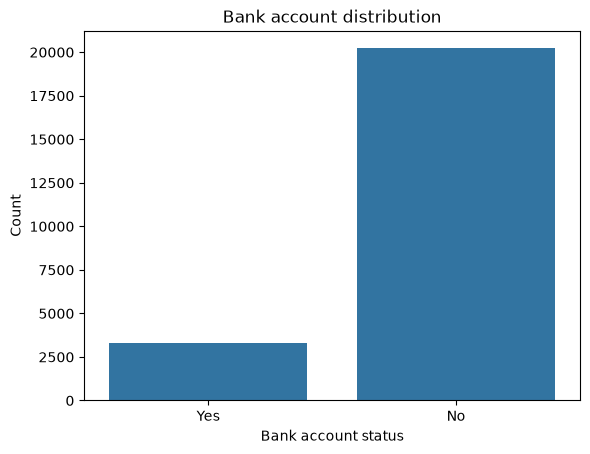

In [20]:
# Check the distributionof the target column 'bank_account'
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=financial_df, x="bank_account")
plt.title("Bank account distribution")
plt.ylabel("Count")
plt.xlabel("Bank account status")
plt.show()

In [ ]:
# Drop the unique_id column and the year column
financial_df.drop(columns=['uniqueid', 'year'], inplace=True)

# Alternatively
# financial_df = financial_df.drop(columns=['uniqueid', 'year'])

__STEP 4:Split the features and the target__

In [26]:
X = financial_df.drop(columns=['bank_account'])
y = financial_df['bank_account']

__STEP 5: Split the data into training and test sets__


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

__STEP 6: Encode categorical features and Scale numerical features__

In [30]:
# ENCODING
# One-Hot encode the categorical features
X_train_categorical_cols = X_train.select_dtypes(include=['str','object']).columns.to_list()
X_test_categorical_cols = X_test.select_dtypes(include=['str','object']).columns.to_list()

X_train_encoded = pd.get_dummies(X_train, columns=X_train_categorical_cols, drop_first=True, dtype=int)
X_test_encoded = pd.get_dummies(X_test, columns=X_test_categorical_cols, drop_first=True, dtype=int)

In [32]:
# SCALING
# Scale the features using StandardScaler
from sklearn.preprocessing import StandardScaler

numerical_cols = X_train.select_dtypes(include=['int','float']).columns.tolist()

scaler = StandardScaler()

X_train_encoded[numerical_cols] = scaler.fit_transform(X_train_encoded[numerical_cols])
X_test_encoded[numerical_cols] = scaler.fit_transform(X_test_encoded[numerical_cols])

__STEP 7: Train the model__

In [35]:
# Load the logistic regression model.   
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_encoded, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

__STEP 8: Evaluate the model__ 

In [38]:
# Import the relvant evalaution metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

y_pred = logistic_model.predict(X_test_encoded)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print("Classification report: ")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test,y_pred))

Accuracy: 0.8852366109379428
Classification report: 
              precision    recall  f1-score   support

          No       0.90      0.97      0.94      6073
         Yes       0.67      0.35      0.46       985

    accuracy                           0.89      7058
   macro avg       0.79      0.66      0.70      7058
weighted avg       0.87      0.89      0.87      7058

Confusion Matrix:
[[5908  165]
 [ 645  340]]


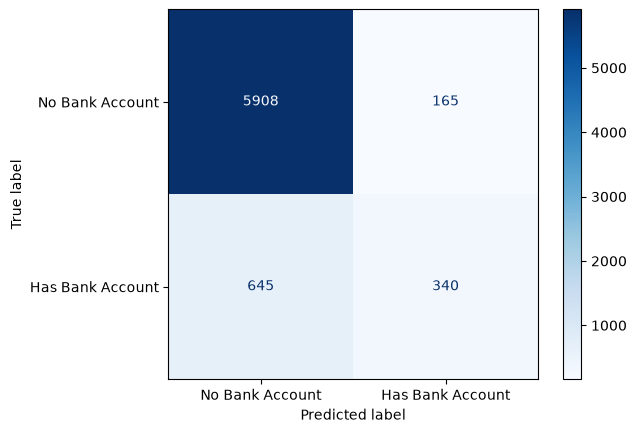

In [39]:
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

labels = ["No Bank Account", "Has Bank Account"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues, values_format='d')

# Display the plot
plt.show()

## 16th July 2026

### 1.2.2 K-Nearest Neighbors Classifer.   
It is a classification and regression classifiers used in Machine learning.     
As a classificication algorithm, KNN operates on the assumption that similar datapoints are located near each other and can grouped in the same category based on their proximity.      

Imagine a dataset containing information about different fruits. Each fruit is categorized by 2 things, We have categorized by its sweetness and by its crunchiness.         
Suppose you have a new fruit you want to classify(X). KNN looks at the K-Nearest point on the graph to this new fruit.      
If most of the nearest points are classified as apples the algorithm will classifiy the new as an apple as well.    

Requirements for a KNN algorithm to achieve its goal:     

##### 1. Distance.   
Distance between a query point and other data points.      
__a). Euclidean Distance__     
Euclidean disatance is defined as the straight-line distance between two points in a plane or space. You can think of it like the shortest path you would walk if you were to go directly from one point to another.      

__b). Manhattan Distance__    
This is the total distance you would travel if you could only move along horizontal and vertical lines like a grid or city streets. It's also called "Taxicab distance" because a taxi can only drive along the grid like streets of a city.      

__c). Minkowski Distance__      
It is like a family of distances, which includes both Euclidean and Manhattan distances as special cases.     

##### 2. Value of K
K-value defines how many neighbors will be checked to determine the classification of a specific query point.        
Choosing the right value of K largely depends on the input data.          
Data with more outliers/noise will likely perform better with higher values of k.       

__Note:__ It is recommended to choose an odd number for k to minimize the chances of ties in classification.      

_Stregths of KNN_     
- Easy to implement.  
- Few Hyper-parameters(k-value and distance)    

_Weaknesses of KNN_     
- As a dataset grows the algorithm becomes less efficient due to increased computational complexity. This is also known as curse of dimensionality.       
If you keep adding mor features, the data points become more sparse in the high dimensional space. The distances between the points starts to become similar. Feature selection and dimensionality reduction techniques can help minimize the curse of dimensionality.       
- Overfitting. Lower values of K can overfit the data whereas higher of K tend to smooth out the prediction values since it is averaging the values over a greater area or neighbourhood.       

#### Hands-On KNN Model

In [43]:
# IMport the KNN model
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN model.  
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')


In [44]:
# Train the KNN model
knn.fit(X_train_encoded, y_train)

,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](2,)","['No','Yes']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [46]:
# Predict from the model.   
knn_pred = knn.predict(X_test_encoded)

In [47]:
# Evaluate the model.   
print("Classification Report: ")
print(classification_report(y_test, knn_pred))
print("Accuracy Score: ", accuracy_score(y_test, knn_pred))

Classification Report: 
              precision    recall  f1-score   support

          No       0.90      0.96      0.93      6073
         Yes       0.60      0.36      0.45       985

    accuracy                           0.88      7058
   macro avg       0.75      0.66      0.69      7058
weighted avg       0.86      0.88      0.86      7058

Accuracy Score:  0.8773023519410598


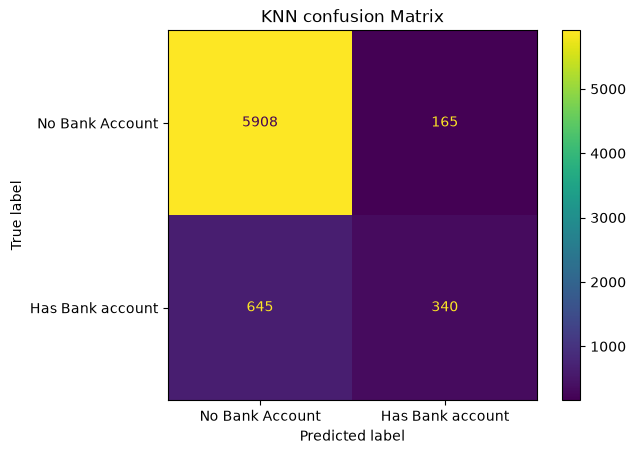

In [51]:
# Confusion Matrix      
cm_knn = confusion_matrix(y_test, knn_pred)

labels = ["No Bank Account", "Has Bank account"]

disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

# Plot
disp_knn.plot(values_format='d')
plt.title("KNN confusion Matrix")
plt.show()

### 1.2.3 Decision Trees
Decision Trees mimic human decision-making by asking a sequence of questions unitil a final prediction is reached.     
A decision tree is a supervised learning algorithm that predicts an outcome by recursively splitting the datset into smaller subsets baed on feature values.       

Each split aims to create groups that are as "pure" as possible, meaning the observations within each group belong predominantly to one class.      

Decision trees can be used for:
- Classification.    
- Regression.          

For example when deciding whether to approve a loan, a bank officer might ask:

```
Is the applicant employed 
        /       \
       No.      Yes
                 |
                 Salary > 80,000?     
                 /          \
                No          Yes
                |            |
               Decline      Approve
```

A decision tree follows the same logic but learns the questions automatically from historical data.     
Example application include , loan approvals, product recommendation.       

__Components of a Decision tree__   
- Root Node: The top node where the first split occurs.  
- Decision Node/internal node: An internal node represents a tesrt on a features.  
- Branch: Represents the outcome of a decision.   
- Leaf Node(Terminal Node): The final prediction.      

_Visual Explainer_     
![Decision Tree](https://media.licdn.com/dms/image/v2/D5612AQE9uNpQLsYuYw/article-cover_image-shrink_720_1280/B56ZXItG_SGUAM-/0/1742829023718?e=1785974400&v=beta&t=cbyBZVU2-V-Z_w2QlMQqChUhERqbr7271Sv3Fwv4IGc)

#### Decision Trees Hands-On

In [55]:
# Import the relevant library    
from sklearn.tree import DecisionTreeClassifier # If you are doing a classification problem.
# from sklearn.tree import DecisionTreeRegressor , If you are doing a regression problem.    

# Instantiate model class
clf = DecisionTreeClassifier(max_depth=3, random_state=42) # The maximum depth of a decision tree is the length of the longest path from the root node to the farthest leaf node

# Train the model
clf.fit(X_train_encoded, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [56]:
# Predict using the test set
clf_pred = clf.predict(X_test_encoded)

In [57]:
# Evaluate the model.   
print("Classification Report: ")
print(classification_report(y_test, clf_pred))

Classification Report: 
              precision    recall  f1-score   support

          No       0.89      0.99      0.94      6073
         Yes       0.76      0.23      0.35       985

    accuracy                           0.88      7058
   macro avg       0.83      0.61      0.64      7058
weighted avg       0.87      0.88      0.85      7058



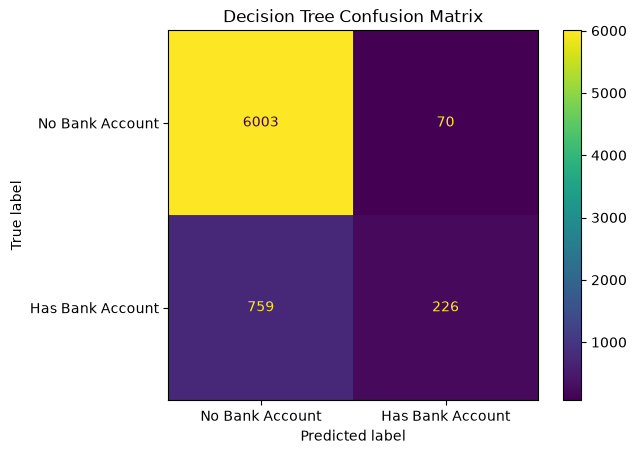

In [58]:
# Confusion Matrix
cm_clf = confusion_matrix(y_test, clf_pred)

labels = ["No Bank Account", "Has Bank Account"]

disp_clf = ConfusionMatrixDisplay(confusion_matrix=cm_clf, display_labels=labels)

# Plot
disp_clf.plot(values_format='d')
plt.title("Decision Tree Confusion Matrix")
plt.show()